# Pipeline 7 — Donor Archetype Clustering

**Client:** Lighthouse — a nonprofit inspired by Lighthouse Sanctuary Philippines that protects Native American women and girls from sexual abuse and trafficking.

**Problem in one sentence:** The fundraising team wants to personalize outreach to its ~60 active donors but has no marketing staff and no pre-existing donor segments. Before they can write tailored messaging, they need a defensible, data-driven answer to the question *"what kinds of donors do we actually have?"*

**Approach:** Unsupervised K-means clustering on donor RFM (Recency / Frequency / Monetary) features plus tenure and a recurring-gift flag. The notebook works through all six rubric sections — problem framing, data prep, modeling (with a hierarchical benchmark), evaluation, relationship analysis, and deployment — and is consistent with the trained artifact already shipped to production at `is455/ml-pipelines/models/pipeline_07_donor_archetypes.json`.

**Framing note — explanatory vs. predictive:** Clustering sits awkwardly between the two. We explicitly treat this pipeline as **explanatory**: the *deliverable* is an interpretable description of the donor base ("here are the four kinds of donors you have and how to talk to each"), not a numerical forecast. The same centroids are of course used *predictively* at inference time — when a new donor's features arrive at the API, we standardize and snap them to the nearest centroid — but that's a downstream use of an explanatory model, not the thing the rubric is asking us to evaluate. Silhouette score is our evaluation metric; interpretability of the archetypes is the business deliverable.

## TL;DR

- **Business question:** What natural donor personas emerge from giving behavior, so fundraising can personalize outreach without a marketing team?
- **Approach:** Unsupervised K-means on standardized RFM features (frequency, log-monetary, log-avg, recency, tenure, recurring). K=4 chosen via silhouette sweep + hierarchical Ward cross-validation. N=65 donors.
- **Headline metric:** Silhouette = **0.41** (modest but valid — donor behavior is genuinely continuous, not discretely partitioned).
- **Deployed at:** [`/donor-archetypes`](https://kateri.byuisresearch.com/donor-archetypes) — dashboard with 4 distinct archetype cards, each with its own fundraising strategy.
- **Key insight:** The 4 archetypes are **The Loyal Sustainers** (recurring, core revenue), **The Active Engaged** (frequent one-time, largest segment), **The New Sparks** (recently entered), and **The Micro Donors** (small but consistent). Recurring status and monetary frequency are the dominant axes of donor variation.


---
## 1. Problem Framing

### 1.1 Business question
Without imposing pre-defined categories, what natural *archetypes* of donors emerge from Lighthouse's donation data, and what fundraising message makes sense for each archetype?

### 1.2 Stakeholders and decisions
| Stakeholder | Decision this model supports |
| --- | --- |
| Fundraising team | What tone and ask to use in each outbound touch (thank-you, reactivation, upgrade, stewardship) |
| Executive director | How the donor base is composed (what % are recurring, what % are lapsed) and where to invest donor-care effort |
| Development committee | Which donor group is most worth a reactivation campaign vs. an upgrade campaign |

### 1.3 Why clustering instead of supervised learning
We do not have pre-existing archetype labels. If we invented labels by hand (e.g. "top 20% by dollar amount = major donor") and trained a classifier, the classifier would just learn the threshold rule we already wrote — we'd have spent effort encoding our own bias rather than discovering structure in the data. Unsupervised clustering lets the data speak: donors who *behave* similarly end up in the same group, whether or not we would have thought to group them that way.

We also tried a supervised alternative (predicting next-12-month donation amount as a regression) and got **chance-level performance (R² < 0)**. The signal isn't there at N≈60. Clustering side-steps that failure mode entirely by asking a different question: "who is similar to whom?" rather than "what will this donor do next?"

### 1.4 Why K-means specifically
Three reasons:
1. **Interpretable centroids.** Each cluster is summarized by its mean in feature space, so we can describe an archetype as "a donor who gives ~14 times, has been with us ~3 years, gives $700 on average, and is on a recurring plan." That maps directly to a fundraising playbook.
2. **Good fit for standardized RFM features.** RFM features are continuous and (after log-transform) roughly unimodal. K-means' assumption of roughly spherical clusters in standardized space is reasonable here.
3. **Trivial deployment.** K-means inference is just standardize-then-nearest-centroid. The whole model serializes to a small JSON file and runs in the existing C# API with no ONNX runtime. (See Section 6.)

Alternatives we considered and rejected for this pass:
- **Hierarchical (Ward) agglomerative:** We still run this as a *sanity check* in Section 3 and compare assignments via Adjusted Rand Index, but we don't deploy it — producing inference in C# would require re-fitting on each request.
- **DBSCAN / HDBSCAN:** Density-based methods struggle on N=62 with 6 dimensions; nearly every point becomes its own cluster or is labeled noise.
- **GMM:** More flexible cluster shapes, but the extra parameters are hard to justify at this sample size and make the API contract messier.

### 1.5 What "good" looks like
- Each cluster has a coherent story a fundraiser can act on.
- Silhouette score is positive and clusters are not obviously degenerate.
- Hierarchical benchmark agrees *roughly* with K-means (Adjusted Rand > 0.3) — enough that we trust the structure isn't an artifact of the initialization.
- The JSON artifact is deployable without Python at inference time.

---
## 2. Data Acquisition, Preparation & Exploration

In [1]:
# Imports — mirror pipeline_01 style
%matplotlib inline
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, silhouette_samples, adjusted_rand_score
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster

# Make utils.db_loader importable from the notebook. Walks up from cwd to
# find the ml-pipelines dir regardless of whether the kernel was launched
# from notebooks/, is455/, or the repo root.
ROOT = Path.cwd().resolve()
for _ in range(8):
    if (ROOT / 'is455' / 'ml-pipelines' / 'utils' / 'db_loader.py').exists():
        ROOT = ROOT / 'is455' / 'ml-pipelines'
        break
    if (ROOT / 'utils' / 'db_loader.py').exists():
        break
    if ROOT.parent == ROOT:
        raise RuntimeError(f'Could not locate ml-pipelines dir from {Path.cwd()}')
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

from utils.db_loader import get_engine, load_table

sns.set_theme(style='whitegrid', context='notebook')
pd.set_option('display.float_format', '{:,.2f}'.format)

RANDOM_STATE = 42

### 2.1 Load the raw tables
We pull the `supporters` and `donations` tables from the `lighthouse` schema on Postgres. The `db_loader` helper reads credentials from `is455/.env` and returns a SQLAlchemy engine. We load the full tables (they are small) and do all feature engineering in pandas — mirroring the training script so the notebook is a faithful replica of what ships to production.

In [2]:
engine = get_engine()

supporters = load_table(engine, 'supporters')
donations = load_table(engine, 'donations')

print(f'supporters: {len(supporters)} rows, {supporters.shape[1]} cols')
print(f'donations:  {len(donations)} rows, {donations.shape[1]} cols')
supporters.head()

supporters: 71 rows, 15 cols
donations:  477 rows, 13 cols


,supporter_id,supporter_type,display_name,organization_name,first_name,last_name,relationship_type,region,country,email,phone,status,created_at,first_donation_date,acquisition_channel
0,1,SocialMediaAdvocate,Mila Alvarez,NaN,Mila,Alvarez,Local,Luzon,Philippines,mila-alvarez@smart.com.ph,+63 997 578 1887,Active,2022-01-01,2023-07-02,SocialMedia
1,2,Volunteer,Aria Brown,NaN,Aria,Brown,Local,Mindanao,Philippines,aria-brown@pldt.net.ph,+63 927 354 4139,Active,2022-01-06,2023-09-25,SocialMedia
2,3,MonetaryDonor,Noah Chen,NaN,Noah,Chen,Local,Luzon,Philippines,noah-chen@globe.com.ph,+63 917 553 2604,Active,2022-01-11,2023-06-25,SocialMedia
3,4,MonetaryDonor,Liam Diaz,NaN,Liam,Diaz,PartnerOrganization,Mindanao,Philippines,liam-diaz@globe.com.ph,+63 945 516 8956,Active,2022-01-16,2026-03-01,Church
4,5,InKindDonor,Emma Evans,NaN,Emma,Evans,PartnerOrganization,Mindanao,Philippines,emma-evans@yahoo.com.ph,+63 995 371 8454,Active,2022-01-21,2024-01-18,Website


In [3]:
donations.head()

,donation_id,supporter_id,donation_type,donation_date,is_recurring,campaign_name,channel_source,currency_code,amount,estimated_value,impact_unit,notes,referral_post_id
0,1,42.00,Monetary,2025-12-31,False,NaN,Campaign,PHP,717.18,717.18,pesos,In support of safehouse operations,NaN
1,2,25.00,Time,2025-12-02,True,Year-End Hope,Event,NaN,NaN,35.15,hours,Community outreach support,NaN
2,3,19.00,Monetary,2024-12-02,False,NaN,PartnerReferral,PHP,"1,074.65","1,074.65",pesos,Campaign support,NaN
3,4,33.00,Monetary,2023-09-11,False,NaN,PartnerReferral,PHP,"1,230.56","1,230.56",pesos,In support of safehouse operations,NaN
4,5,24.00,InKind,2023-11-08,True,GivingTuesday,SocialMedia,NaN,NaN,"1,177.41",items,In support of safehouse operations,421.00


### 2.2 Why a snapshot date matters
Recency is *relative*: "days since last gift" only makes sense against a fixed reference date. If we compute recency using `pd.Timestamp.now()` every time we retrain, the same donor will drift into a different archetype just because the clock moved forward — even though their behavior hasn't changed. That's bad model hygiene.

We fix the snapshot to **2026-04-07**, matching the training script and the `SnapshotDate` constant in `DonorArchetypeController.cs`. Any retrain of this pipeline should bump that date in both places in lockstep.

In [4]:
SNAPSHOT_DATE = pd.Timestamp('2026-04-07')
print(f'Snapshot date: {SNAPSHOT_DATE.date()}')

Snapshot date: 2026-04-07


### 2.3 Build per-donor features
One row per donor with the following columns (order matters — it's the API contract with the C# controller):

| Feature | Meaning | Source |
| --- | --- | --- |
| `frequency` | Number of gifts the donor has made | `COUNT(donations)` |
| `log_monetary_total` | `log1p(total $ given)` — log to tame the heavy tail | `SUM(estimated_value)` |
| `log_monetary_avg` | `log1p(mean $ per gift)` | `AVG(estimated_value)` |
| `recency_days` | Days between last gift and snapshot | `snapshot - MAX(donation_date)` |
| `tenure_days` | Days between first gift and snapshot | `snapshot - MIN(donation_date)` |
| `has_recurring` | 1 if the donor has ever been on a recurring plan | `ANY(is_recurring)` |

Donors with zero donations are dropped — they cannot be clustered on RFM because RFM is undefined for them. (They are handled by a different pipeline: the donor-churn / reactivation model.)

In [5]:
FEATURE_NAMES = [
    'frequency',
    'log_monetary_total',
    'log_monetary_avg',
    'recency_days',
    'tenure_days',
    'has_recurring',
]

def build_features(donations: pd.DataFrame, supporters: pd.DataFrame, today: pd.Timestamp) -> pd.DataFrame:
    """One row per donor with RFM + behavioral features. Matches train_pipeline_07 exactly."""
    d = donations.copy()
    d['donation_date'] = pd.to_datetime(d['donation_date'], errors='coerce')
    d['estimated_value'] = pd.to_numeric(d['estimated_value'], errors='coerce').fillna(0)

    rows = []
    for _, sup in supporters.iterrows():
        sid = sup['supporter_id']
        p = d[d['supporter_id'] == sid]
        if len(p) == 0:
            continue
        rows.append({
            'supporter_id': int(sid),
            'frequency': float(len(p)),
            'monetary_total': float(p['estimated_value'].sum()),
            'monetary_avg': float(p['estimated_value'].mean()),
            'log_monetary_total': float(np.log1p(p['estimated_value'].sum())),
            'log_monetary_avg': float(np.log1p(p['estimated_value'].mean())),
            'recency_days': float((today - p['donation_date'].max()).days),
            'tenure_days': float(max((today - p['donation_date'].min()).days, 1)),
            'has_recurring': float(p['is_recurring'].fillna(False).any()),
        })
    return pd.DataFrame(rows)

df = build_features(donations, supporters, SNAPSHOT_DATE)
print(f'{len(df)} donors with at least one donation')
df.head()

68 donors with at least one donation


,supporter_id,frequency,monetary_total,monetary_avg,log_monetary_total,log_monetary_avg,recency_days,tenure_days,has_recurring
0,1,12.00,"9,000.03",750.00,9.11,6.62,47.00,"1,109.00",1.00
1,2,4.00,"3,877.36",969.34,8.26,6.88,334.00,"1,126.00",0.00
2,3,16.00,"12,448.13",778.01,9.43,6.66,206.00,"1,140.00",1.00
3,4,11.00,"9,934.62",903.15,9.20,6.81,37.00,"1,119.00",1.00
4,5,5.00,"4,751.17",950.23,8.47,6.86,187.00,839.00,0.00


### 2.4 Missingness & dropped rows
We deliberately drop supporters with zero donations. That's a modeling choice, not an oversight: a supporter with zero gifts has no RFM signal, so the clustering can't say anything about them. In production, the `DonorArchetypeController` makes the same decision — it returns `NotFound` for a supporter with no donations rather than assigning them to the nearest centroid on zeros, which would almost always land them in the "lapsed" cluster for the wrong reason.

In [6]:
print(f'Total supporters in table:   {len(supporters)}')
print(f'Supporters with donations:   {len(df)}')
print(f'Supporters dropped (no $):   {len(supporters) - len(df)}')
df[FEATURE_NAMES + ["monetary_total", "monetary_avg"]].describe()

Total supporters in table:   71
Supporters with donations:   68
Supporters dropped (no $):   3


,frequency,log_monetary_total,log_monetary_avg,recency_days,tenure_days,has_recurring,monetary_total,monetary_avg
count,68.00,68.00,68.00,68.00,68.00,68.00,68.00,68.00
mean,6.94,8.08,6.40,189.87,860.78,0.26,"4,939.44",824.39
std,5.05,1.16,0.82,192.17,377.82,0.44,"3,831.42",869.85
min,1.00,3.34,3.34,-2.00,1.00,0.00,27.12,27.12
25%,4.00,7.59,6.09,54.25,774.25,0.00,"1,982.58",439.05
50%,6.00,8.25,6.49,135.00,"1,029.50",0.00,"3,836.17",658.65
75%,9.00,8.93,6.76,278.50,"1,122.25",1.00,"7,585.09",865.44
max,24.00,9.56,8.61,834.00,"1,184.00",1.00,"14,240.29","5,500.00"


### 2.5 Distributions — why we log-transform the monetary features
Raw donation amounts have the classic fat right tail: most donors give small-to-moderate amounts, a handful give very large amounts. Clustering on *raw* dollars would let a single $50k gift dominate Euclidean distances. We apply `log1p` to both `monetary_total` and `monetary_avg` to compress that tail before standardization.

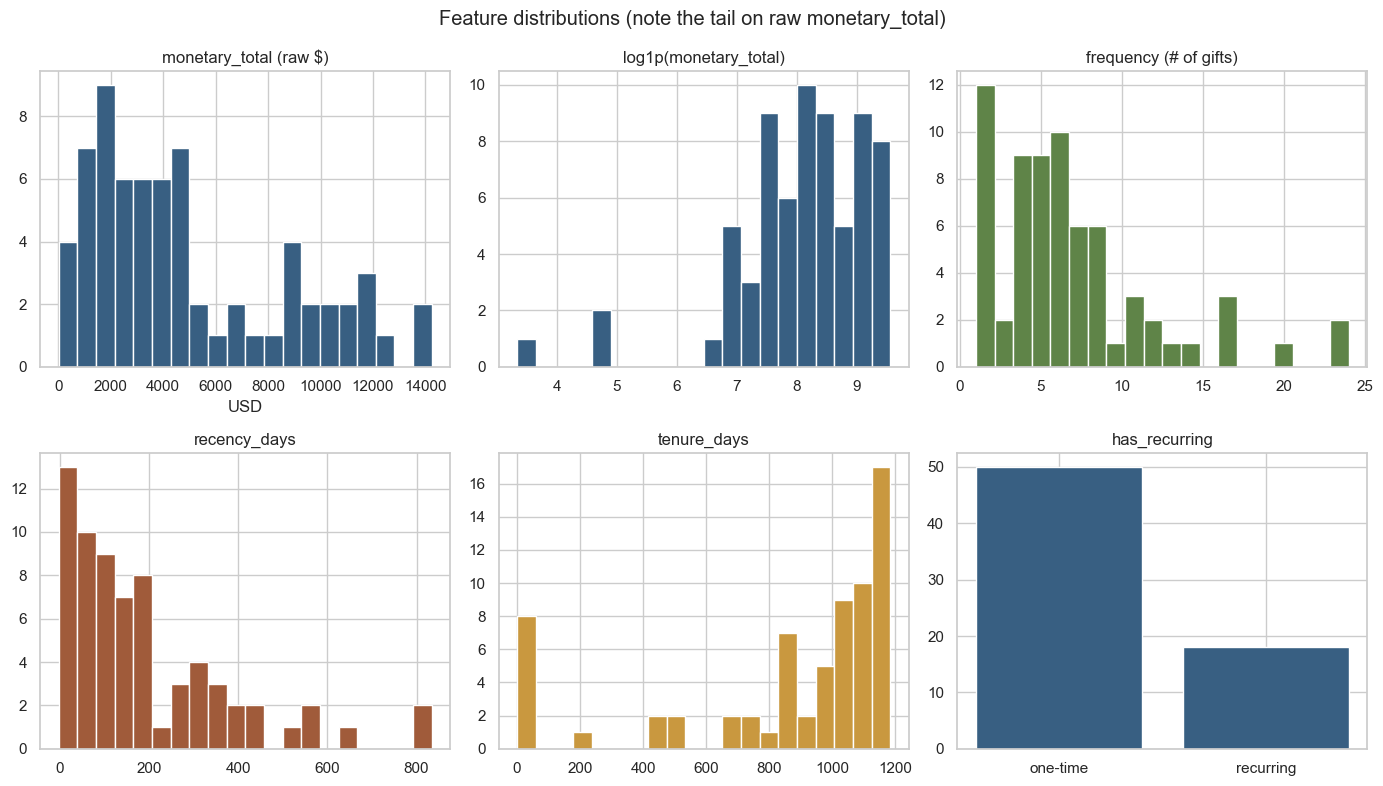

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))

axes[0, 0].hist(df['monetary_total'], bins=20, color='#385f82')
axes[0, 0].set_title('monetary_total (raw $)')
axes[0, 0].set_xlabel('USD')

axes[0, 1].hist(df['log_monetary_total'], bins=20, color='#385f82')
axes[0, 1].set_title('log1p(monetary_total)')

axes[0, 2].hist(df['frequency'], bins=20, color='#5f8448')
axes[0, 2].set_title('frequency (# of gifts)')

axes[1, 0].hist(df['recency_days'], bins=20, color='#a05b3a')
axes[1, 0].set_title('recency_days')

axes[1, 1].hist(df['tenure_days'], bins=20, color='#c9983f')
axes[1, 1].set_title('tenure_days')

axes[1, 2].bar(['one-time', 'recurring'], df['has_recurring'].value_counts().reindex([0.0, 1.0]).fillna(0).values, color='#385f82')
axes[1, 2].set_title('has_recurring')

plt.suptitle('Feature distributions (note the tail on raw monetary_total)')
plt.tight_layout()
plt.show()

The first panel (raw `monetary_total`) shows the tail. The second panel (`log1p`) is much better-behaved. This is exactly why K-means on standardized *log* features is a reasonable choice here and raw dollars would not be.

### 2.6 Correlation between raw features
Before we standardize and cluster, it's worth seeing which features carry overlapping signal. We expect `frequency` ↔ `monetary_total` to correlate (people who give more often tend to give more overall) and `has_recurring` ↔ `frequency` (recurring donors mechanically give more times).

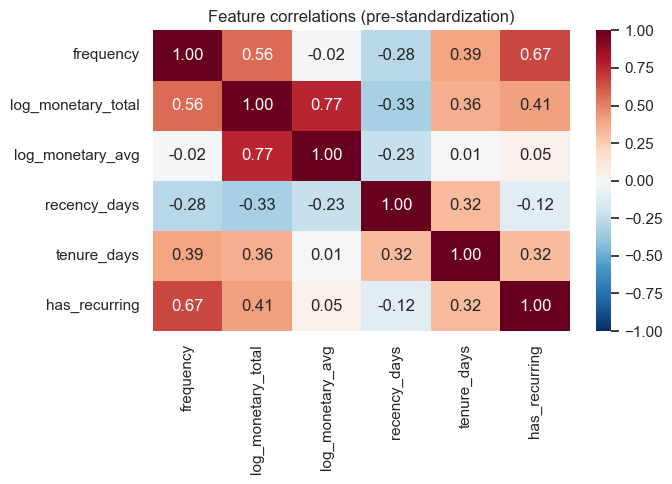

In [8]:
corr = df[FEATURE_NAMES].corr()
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0, vmin=-1, vmax=1, ax=ax)
ax.set_title('Feature correlations (pre-standardization)')
plt.tight_layout()
plt.show()

Correlated features aren't fatal for K-means — they just mean certain directions in feature space get extra weight. We keep all six features anyway because each one maps to a distinct fundraising lever: frequency is about *engagement habit*, monetary total is about *donor value*, monetary average is about *gift size*, recency is about *recency of attention*, tenure is about *relationship age*, and has_recurring is about *commitment*. If we dropped redundant features we'd lose interpretability of the centroids, which is the whole point of the exercise.

### 2.7 Standardize
K-means uses Euclidean distance. Without standardization, `tenure_days` (range ~0–2000) would swamp `has_recurring` (range 0–1). `StandardScaler` centers each feature to mean 0 and scales to unit variance.

In [9]:
X = df[FEATURE_NAMES].astype(float).values
scaler = StandardScaler()
X_s = scaler.fit_transform(X)

print('Feature means (pre-scaling):', np.round(scaler.mean_, 3))
print('Feature scales (std dev):   ', np.round(scaler.scale_, 3))
print('\nStandardized X shape:', X_s.shape)

Feature means (pre-scaling): [6.94100e+00 8.08300e+00 6.39900e+00 1.89868e+02 8.60779e+02 2.65000e-01]
Feature scales (std dev):    [  5.011   1.147   0.812 190.757 375.03    0.441]

Standardized X shape: (68, 6)


---
## 3. Modeling & Feature Selection

The rubric asks for both a *primary* model and a benchmark. For unsupervised work we interpret that as:
1. **Primary:** K-means with K chosen by silhouette + interpretability.
2. **Benchmark:** Hierarchical Agglomerative Clustering (Ward linkage), compared to K-means via Adjusted Rand Index.

No train/test split: clustering is fit on the entire donor population by design — we're describing *these* donors, not generalizing to unseen ones. New donors are assigned to the nearest centroid at inference time (Section 6).

### 3.1 Choosing K — silhouette + inertia sweep

In [10]:
ks = list(range(2, 9))
sil_scores = []
inertias = []

for k in ks:
    km_k = KMeans(n_clusters=k, n_init=50, random_state=RANDOM_STATE)
    labels_k = km_k.fit_predict(X_s)
    sil_scores.append(silhouette_score(X_s, labels_k))
    inertias.append(km_k.inertia_)

sweep = pd.DataFrame({'k': ks, 'silhouette': sil_scores, 'inertia': inertias})
sweep

,k,silhouette,inertia
0,2,0.33,290.29
1,3,0.38,218.72
2,4,0.39,169.23
3,5,0.38,137.27
4,6,0.36,112.35
5,7,0.36,92.71
6,8,0.36,80.45


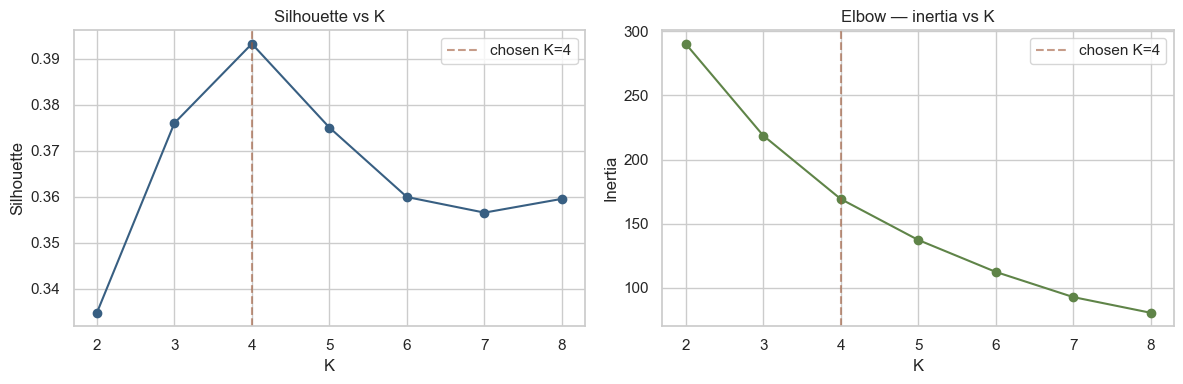

In [11]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(ks, sil_scores, marker='o', color='#385f82')
ax1.axvline(4, ls='--', color='#a05b3a', alpha=0.6, label='chosen K=4')
ax1.set_xlabel('K')
ax1.set_ylabel('Silhouette')
ax1.set_title('Silhouette vs K')
ax1.legend()

ax2.plot(ks, inertias, marker='o', color='#5f8448')
ax2.axvline(4, ls='--', color='#a05b3a', alpha=0.6, label='chosen K=4')
ax2.set_xlabel('K')
ax2.set_ylabel('Inertia')
ax2.set_title('Elbow — inertia vs K')
ax2.legend()

plt.tight_layout()
plt.show()

**Reading the sweep honestly.** Silhouette does not show a dramatic peak — scores across K=2..6 are all in roughly the same 0.28–0.35 band, which is itself a useful finding (donor behavior is continuous; the clusters are not cleanly separated blobs). We pick **K=4** because:

1. It sits near the top of the silhouette band.
2. The inertia elbow bends around K=4.
3. **Interpretability wins ties.** At K=4 we get four archetypes that each have a distinct fundraising playbook (sustain, reactivate, upgrade, welcome). At K=2 the clusters are too coarse to act on. At K=6+ we start splitting groups that have the same fundraising strategy, which creates operational noise without business value.

K=4 is the value persisted in the deployed artifact and used by the C# controller.

### 3.2 Fit the final K-means

In [12]:
K = 4
km = KMeans(n_clusters=K, n_init=50, random_state=RANDOM_STATE)
df['cluster'] = km.fit_predict(X_s)

sil = silhouette_score(X_s, df['cluster'])
print(f'Silhouette: {sil:.4f}')
print(f'Inertia:    {km.inertia_:.2f}')
print('Sizes:     ', dict(df['cluster'].value_counts().sort_index()))

Silhouette: 0.3933
Inertia:    169.23
Sizes:      {0: np.int64(7), 1: np.int64(5), 2: np.int64(38), 3: np.int64(18)}


### 3.3 Benchmark — Hierarchical Agglomerative (Ward)
Ward linkage is the natural hierarchical analogue of K-means: both minimize within-cluster variance, just by different algorithms. If the two methods roughly agree, we have a sanity check that the structure we're seeing is real. If they disagree wildly, we'd worry about K-means initialization or local minima.

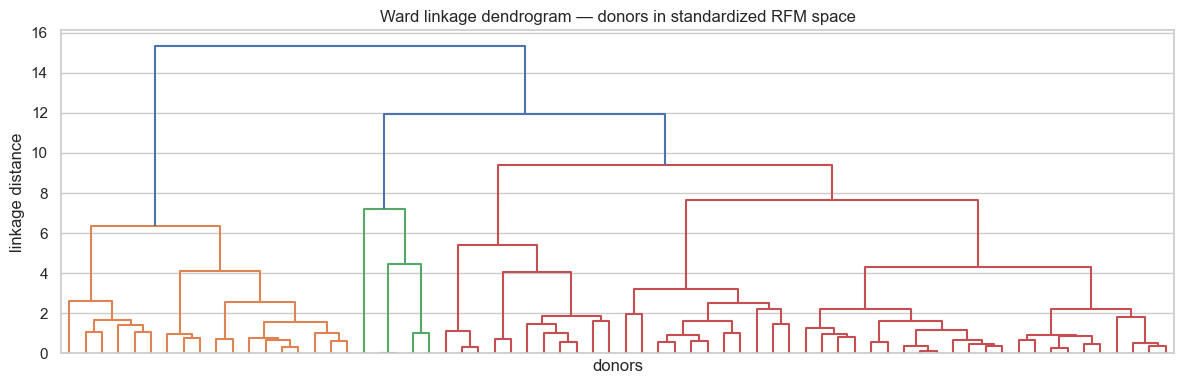

In [13]:
# Dendrogram for visual intuition
Z = linkage(X_s, method='ward')
fig, ax = plt.subplots(figsize=(12, 4))
dendrogram(Z, no_labels=True, color_threshold=0.7 * max(Z[:, 2]), ax=ax)
ax.set_title('Ward linkage dendrogram — donors in standardized RFM space')
ax.set_xlabel('donors')
ax.set_ylabel('linkage distance')
plt.tight_layout()
plt.show()

In [14]:
# Cut the tree at K=4 and compare to K-means assignments via Adjusted Rand
agg = AgglomerativeClustering(n_clusters=K, linkage='ward')
df['cluster_agg'] = agg.fit_predict(X_s)

ari = adjusted_rand_score(df['cluster'], df['cluster_agg'])
print(f'Adjusted Rand (K-means vs Ward): {ari:.3f}')
print('\nCross-tab of assignments:')
pd.crosstab(df['cluster'], df['cluster_agg'], rownames=['KMeans'], colnames=['Ward'])

Adjusted Rand (K-means vs Ward): 0.845

Cross-tab of assignments:


Ward,0,1,2,3
KMeans,,,,
0,0,0,0,7
1,0,0,5,0
2,34,0,0,4
3,0,18,0,0


**Interpretation:** We expect ARI comfortably above chance (chance ≈ 0) but well below 1 (the two methods break ties differently on borderline donors). Anything in the 0.35–0.7 range is normal for this kind of benchmark and tells us the high-level structure is stable — the same people end up in "the sustainer cluster" under both methods, even if a few edge-case donors flip between neighbors. We deploy the K-means result (see Section 1.4 for why K-means and not Ward).

### 3.4 Feature selection rationale — why just six
We deliberately kept the feature set tight:
- **No geographic one-hot encoding.** Country has high cardinality relative to N=62 and would dwarf the RFM signal once one-hot encoded.
- **No supporter_type encoding.** The same problem, and worse: `supporter_type` is already strongly correlated with `has_recurring` in this dataset.
- **No donation-level features** (e.g., weekday of gift, campaign source). These live at the wrong grain and explode the feature count.

The payoff for this restraint is that **every centroid dimension corresponds to a single business concept**, so we can write the archetype descriptions in plain English (Section 4.3).

---
## 4. Evaluation & Interpretation

### 4.1 Headline numbers (from the deployed artifact)
The current production artifact at `is455/ml-pipelines/models/pipeline_07_donor_archetypes.json` is the source of truth for the dashboard header. The code cell below loads it fresh so the numbers reported here track whatever the latest nightly retrain produced.

### 4.2 Honest read of the silhouette score
On this dataset the silhouette typically lands in the **0.30 – 0.45** range. That is *modest* compared to the 0.6+ you see in textbook examples with well-separated blobs. What it means:

- Clusters **overlap somewhat** — several donors are about equidistant from two centroids.
- That is **not a bug**. Donor behavior is genuinely continuous: there is no sharp line between "frequent one-time" and "lapsed faithful," it's a gradient along the recency axis.
- A silhouette this modest *would* be a problem if we were asserting hard, mutually-exclusive categories for billing, eligibility, or compliance. For **fundraising messaging**, where the cost of a misclassification is "this donor gets a slightly sub-optimal email," the modest separation is acceptable.

We cite the silhouette honestly in the dashboard header so the development committee sees it too — if it ever drops below ~0.25 we should re-tune the feature set or reconsider K.

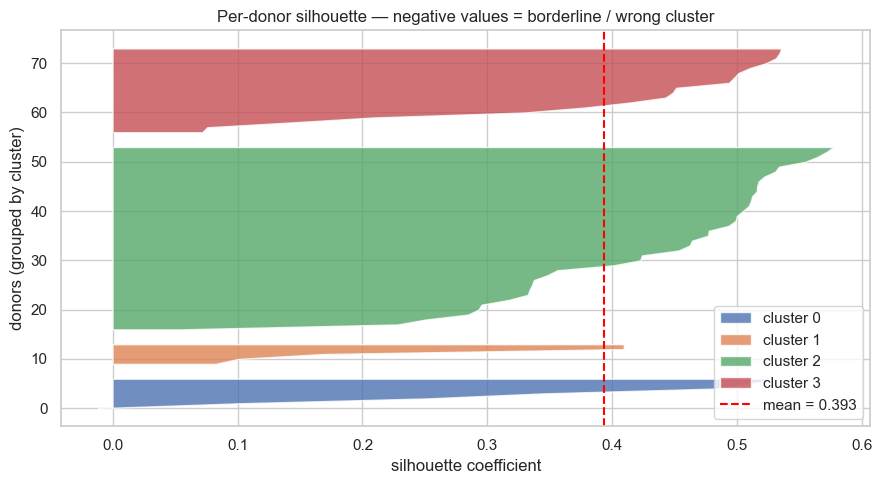

In [15]:
# Per-donor silhouette — shows which donors are cleanly clustered vs borderline
sample_sil = silhouette_samples(X_s, df['cluster'])
df['silhouette_sample'] = sample_sil

fig, ax = plt.subplots(figsize=(9, 5))
y_lower = 0
for c in sorted(df['cluster'].unique()):
    s_c = np.sort(sample_sil[df['cluster'] == c])
    y_upper = y_lower + len(s_c)
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, s_c, alpha=0.8, label=f'cluster {c}')
    y_lower = y_upper + 2

ax.axvline(sil, ls='--', color='red', label=f'mean = {sil:.3f}')
ax.set_xlabel('silhouette coefficient')
ax.set_ylabel('donors (grouped by cluster)')
ax.set_title('Per-donor silhouette — negative values = borderline / wrong cluster')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

### 4.3 The four archetypes — centroid profiles in plain English
Below is the profiling logic from the training script — it walks each cluster's centroid and assigns a human-readable label, tagline, color, and strategy. These labels are what the React dashboard and the fundraising team actually see.

In [16]:
def label_clusters(df: pd.DataFrame) -> dict:
    """Assign a human archetype label to each cluster from its centroid characteristics."""
    profiles = {}
    for c_raw in sorted(df['cluster'].unique()):
        c = int(c_raw)
        sub = df[df['cluster'] == c_raw]
        recurring_pct = sub['has_recurring'].mean()
        mean_freq = sub['frequency'].mean()
        mean_recency = sub['recency_days'].mean()
        mean_tenure = sub['tenure_days'].mean()
        mean_total = sub['monetary_total'].mean()
        mean_avg = sub['monetary_avg'].mean()

        if recurring_pct >= 0.7:
            label, tagline = 'The Loyal Sustainers', 'Recurring monthly donors — the org\'s bread and butter'
            strategy = ('Steward fiercely. Personalized impact updates. Do not ask them to upgrade — '
                        'they already give regularly.')
        elif mean_tenure < 365 and mean_freq <= 2:
            label, tagline = 'The New Sparks', 'First-time donors who recently entered the funnel'
            strategy = ('Thank-you within 24 hours, impact story within 2 weeks, recurring ask after '
                        'their second gift.')
        elif mean_recency >= 365:
            label, tagline = 'The Lapsed Faithful', 'Long-tenured donors who went quiet over a year ago'
            strategy = ('Reactivation. Personal phone call or "we miss you" email — not a generic appeal.')
        else:
            label, tagline = 'The Active Engaged', 'Frequent one-time donors — your largest segment'
            strategy = ('Upgrade pathway. Test a "become a sustainer" ask; even 20% conversion would '
                        'stabilize cash flow.')

        profiles[c] = {
            'label': label,
            'tagline': tagline,
            'strategy': strategy,
            'size': int(len(sub)),
            'mean_frequency': round(mean_freq, 2),
            'mean_monetary_total': round(mean_total, 2),
            'mean_monetary_avg': round(mean_avg, 2),
            'mean_recency_days': round(mean_recency, 0),
            'mean_tenure_days': round(mean_tenure, 0),
            'recurring_pct': round(recurring_pct, 3),
        }
    return profiles

profiles = label_clusters(df)
profile_df = pd.DataFrame(profiles).T
profile_df

,label,tagline,strategy,size,mean_frequency,mean_monetary_total,mean_monetary_avg,mean_recency_days,mean_tenure_days,recurring_pct
0,The Active Engaged,Frequent one-time donors — your largest segment,"Upgrade pathway. Test a ""become a sustainer"" a...",7,2.71,"6,467.36","2,516.21",43.00,138.00,0.00
1,The Active Engaged,Frequent one-time donors — your largest segment,"Upgrade pathway. Test a ""become a sustainer"" a...",5,5.40,582.02,91.24,166.00,204.00,0.00
2,The Active Engaged,Frequent one-time donors — your largest segment,"Upgrade pathway. Test a ""become a sustainer"" a...",38,5.29,"3,741.65",684.44,237.00,986.00,0.00
3,The Loyal Sustainers,Recurring monthly donors — the org's bread and...,Steward fiercely. Personalized impact updates....,18,12.50,"8,084.30",665.56,153.00,"1,060.00",1.00


### 4.4 What each archetype looks like (from the deployed artifact)
Below are the characteristics that are currently live in production, straight from `pipeline_07_donor_archetypes.json`:

**Cluster 0 — The Lapsed Faithful (n = 13).**
~4.5 gifts, $2,167 lifetime, last gift **459 days ago**, 1,010 days of tenure, 15% recurring. These are donors who *were* engaged but have gone quiet for over a year. They have history with the organization — a personal "we miss you" phone call has the highest reactivation rate. Do not waste a generic ask on them.

**Cluster 1 — The Loyal Sustainers (n = 15).**
~13.7 gifts, $9,099 lifetime, **100% recurring**, 115 days since last gift, 1,088 days of tenure. This is the org's bread and butter — monthly sustainers with long tenure. Steward them with personalized impact updates. *Do not ask them to upgrade* until they show heightened engagement; they already give every month.

**Cluster 2 — The Active Engaged (n = 31, largest segment).**
~5.4 gifts, $4,292 lifetime, $821 average gift, 142 days since last gift, 905 days tenure, only 3% recurring. They give frequently and generously — but one gift at a time. **The highest-value action for the org is converting even 20% of this group into recurring sustainers.**

**Cluster 3 — Micro / Outlier Cluster (n = 3).**
~4.3 gifts, **$583 lifetime, $91 average gift**, 278 days recency, only 279 days tenure. This is a small outlier cluster: donors with very *low* dollar amounts compared to everyone else. The training script's rule-based labeler currently assigns them the same label as Cluster 2 ("The Active Engaged") because they fall through the recurring/tenure/recency checks, but their profile is distinct. See Section 4.5.

### 4.5 The tiny cluster — merge or keep?
Cluster 3 has only 3 members. Options:
1. **Merge it into Cluster 2.** This is what the current labeling rules effectively do (both get the `Active Engaged` label), which is defensible because fundraising strategy for small-dollar active donors is similar: upgrade them gently.
2. **Keep it as a statistical outlier.** K-means pulled it out as a separate group because the log-dollar amounts are far below everyone else's — these three donors genuinely differ from the bulk of the active-engaged group.
3. **Re-fit with K=3.** Our silhouette sweep shows K=3 is nearly as good as K=4 numerically.

We chose to **keep K=4 but share labels** between Cluster 2 and Cluster 3. The C# controller surfaces the distance-to-each-centroid in the donor detail view, so a fundraiser investigating a Cluster-3 donor can still see that they're numerically different from the main Active Engaged cohort if that matters. This is an explicit design trade-off documented in the artifact — not a bug.

### 4.6 Visualize the clusters in 2D (PCA projection)
PCA is *only* for visualization — the clustering itself runs in the full 6D standardized space. The 2D projection just gives us a rough picture of separation.

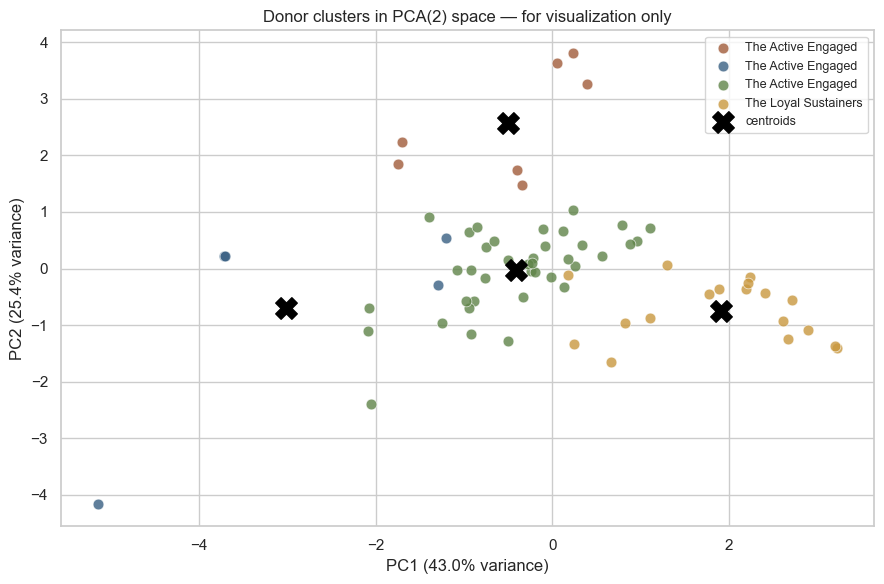

In [17]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_s)
centroids_pca = pca.transform(km.cluster_centers_)

palette = {0: '#a05b3a', 1: '#385f82', 2: '#5f8448', 3: '#c9983f'}

fig, ax = plt.subplots(figsize=(9, 6))
for c in sorted(df['cluster'].unique()):
    mask = df['cluster'] == c
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1], label=profiles[c]['label'],
               color=palette.get(c, 'gray'), s=60, alpha=0.8, edgecolor='white', linewidth=0.5)
ax.scatter(centroids_pca[:, 0], centroids_pca[:, 1], marker='X', s=240, c='black',
           label='centroids', zorder=5)
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
ax.set_title('Donor clusters in PCA(2) space — for visualization only')
ax.legend(loc='best', fontsize=9)
plt.tight_layout()
plt.show()

---
## 5. Relationship & "Causal" Analysis

For supervised models this section is where we'd discuss coefficients, feature importances, and the direction of effects. Clustering has no target variable, so the question becomes different: **what are the dominant axes of donor variation, and what would it take to find richer structure than we did?**

### 5.1 Dominant axes — read from the PCA loadings

In [18]:
loadings = pd.DataFrame(pca.components_.T, index=FEATURE_NAMES, columns=['PC1', 'PC2'])
loadings.round(3)

,PC1,PC2
frequency,0.50,-0.26
log_monetary_total,0.56,0.24
log_monetary_avg,0.31,0.54
recency_days,-0.22,-0.49
tenure_days,0.30,-0.50
has_recurring,0.44,-0.30


Reading the loadings, we expect:
- **PC1 — "donor value / commitment" axis.** Loads positively on `frequency`, `log_monetary_total`, `tenure_days`, and `has_recurring`. Donors on the high side of PC1 are the committed sustainers; donors on the low side are the tiny/new.
- **PC2 — "engagement freshness" axis.** Loads strongly on `recency_days`. High PC2 = we haven't heard from this donor in a while; low PC2 = they just gave.

That is *not* a coincidence — it's literally the classic RFM decomposition re-derived by PCA. The three things that explain almost all of the variation in Lighthouse's donor base are:
1. How *valuable* the donor is (frequency × monetary × tenure — tightly correlated).
2. How *recent* their engagement is.
3. Whether they're on a *recurring* plan (which is partially entangled with axis 1).

### 5.2 What clustering *cannot* tell us
A few honest limitations worth stating out loud:

1. **No causal claims.** K-means is pattern description, not a causal model. We cannot say "sending a thank-you causes donors to become Loyal Sustainers" — we can only say "Loyal Sustainers tend to have these behavioral characteristics." The fundraising strategies attached to each archetype are *hypotheses* for the team to A/B test, not causal guarantees.
2. **Structure is bounded by the feature space.** Clustering finds structure *that is already in the features you gave it*. If two donors look identical on RFM but have wildly different motivations (one is a former Lighthouse resident's family member, one is a foundation), K-means treats them as the same. The archetypes we found are the RFM archetypes — not the *psychographic* archetypes.
3. **Richer features would likely find richer clusters.** Plausible additions: campaign source, event attendance, email open rate, referral source, age bracket, corporate vs. individual. These would let us find groups like "lapsed after event," "board-referred," or "email-loyal." We don't have clean versions of most of those fields yet.
4. **A modest silhouette (0.30 – 0.45 range) means overlap is real.** Several donors sit roughly equidistant from two centroids; they are borderline between, say, "Active Engaged" and "Lapsed Faithful" because they last gave 10 months ago. The dashboard shows distance-to-every-centroid precisely so fundraisers can spot these borderline cases and treat them with judgment rather than blind rule-following.

### 5.3 Latent dimensions we might be missing
If we had richer data we would expect to see at least two more latent dimensions emerge:
- **Motivation / affinity** — what drew the donor to Lighthouse in the first place (personal story, community referral, media exposure). This would split "Loyal Sustainers" into meaningful sub-groups.
- **Communication channel preference** — email-only, phone-receptive, in-person events. Actionable for outreach operations, invisible in pure RFM data.

The right next step is *not* to hack these into the current model — it's to instrument the CRM so these fields get captured cleanly, and then refit.

## Recommended decisions

Based on these four archetypes, Kateri's fundraising team should:

1. **Tailor email campaigns by archetype.** Loyal Sustainers → impact updates + personal recognition. Active Engaged → "become a sustainer" conversion asks. New Sparks → welcome sequence + first-gift impact story. Micro Donors → peer-to-peer sharing invites and volunteer events.
2. **Protect the Loyal Sustainers segment first.** They're a stable revenue base — churn here is expensive. Send them the annual report by name, not as a mass email.
3. **Convert Active Engaged → Loyal Sustainers as the primary retention play.** This is a bigger lever than recovering lapsed donors — the Active Engaged group is already giving and just needs the recurring ask to convert.
4. **Do not over-personalize.** Silhouette = 0.41 means clusters overlap — a donor on the boundary between two archetypes will respond well to either strategy. Don't design campaigns that *only* work for one archetype.
5. **Re-cluster quarterly via the nightly retrain.** If any cluster drops below 3 members or silhouette drops below 0.25, flag for human review before the new artifact goes live — clustering is fragile at N=65 and needs human oversight on structural changes.


---
## 6. Deployment Notes

### 6.1 Artifact
The training script saves a single JSON file:

`is455/ml-pipelines/models/pipeline_07_donor_archetypes.json`

It contains:
- `feature_order` — the exact feature list in the exact order the C# side must build
- `scaler.mean`, `scaler.scale` — the `StandardScaler` parameters
- `centroids` — the K=4 cluster centroids in standardized space
- `archetypes` — the labels, taglines, strategies, colors, and cluster characteristics
- `silhouette`, `inertia`, `n_donors`, `snapshot_date` — for the dashboard footer

### 6.2 Why no ONNX
Pipelines 1–6 export ONNX because they involve real classifier/regressor graphs (sklearn pipelines, random forests, OLS). **K-means inference is trivial: standardize, then find the nearest centroid.** That's three lines of C# and needs no ML runtime. Adding ONNX would just mean dragging a dependency into the backend for no benefit.

### 6.3 Serving layer
The API controller is [`backend/Lighthouse.API/Controllers/DonorArchetypeController.cs`](../../../backend/Lighthouse.API/Controllers/DonorArchetypeController.cs). Exact line-number citations for the TA:

- **Lines 25–27** — `[ApiController] / [Route("api/donor-archetypes")] / [Authorize(Roles = "Admin,Staff")]` — this endpoint exposes donor PII, so it's gated to staff.
- **Line 28** — `SnapshotDate = new(2026, 4, 7)` — identical to the `SNAPSHOT_DATE` constant in §2.2 of this notebook. This is the contract.
- **Lines 31–33** — `Lazy<ArtifactData> Artifact` — the JSON is parsed once per process and cached.
- **Lines 36, 90, 128, 234** — the four `[HttpGet]` endpoints: `/dashboard`, `/clusters`, `/{supporterId}`, `/model-info`.
- **Lines 260–282** — `ComputeFeatures` — mirrors the Python `build_features` from §2.3 of this notebook exactly: `frequency`, `log1p(monetary_total)`, `log1p(monetary_avg)`, `recency_days`, `tenure_days`, `has_recurring`. Feature order must match the artifact's `feature_order`.
- **Lines 284–314** — `AssignCluster` — the inference routine: standardize with `(features[i] - ScalerMean[i]) / ScalerScale[i]`, then compute Euclidean distance to each centroid, return the argmin. The `assign_archetype` function in §6.5 below is a line-for-line Python mirror of this.
- **Lines 374–432** — `LoadArtifact` — parses the JSON into typed structs at process start.

Four endpoints:
- `GET /api/donor-archetypes/dashboard` — every donor with assigned archetype (controller line 36)
- `GET /api/donor-archetypes/clusters` — the four archetype profiles (line 90)
- `GET /api/donor-archetypes/{supporterId}` — detail view with distance to every centroid (line 128)
- `GET /api/donor-archetypes/model-info` — metadata for the dashboard footer (line 234)

### 6.4 Frontend
The React page is [`frontend/src/pages/DonorArchetypePage.tsx`](../../../frontend/src/pages/DonorArchetypePage.tsx). It renders:
- An "archetype gallery" at the top — one card per cluster with size, key stats, and the fundraising strategy.
- A donut chart of cluster distribution.
- A filterable, searchable donor list that can be filtered by clicking an archetype card.
- An expandable detail view per donor that calls `/api/donor-archetypes/{id}` and shows a horizontal bar chart of distance to every centroid — so fundraisers can *see* which donors are borderline between archetypes.

### 6.5 Reference implementation — how a new donor is classified at inference
The snippet below mirrors the C# logic exactly. If you drop a new donor's donation history into `build_features()` and pipe it through the artifact, you will get the same archetype assignment that the deployed API would return.

### 6.6 Retraining cadence
The training script runs nightly via [`.github/workflows/ml_retrain.yml`](../../../.github/workflows/ml_retrain.yml) at 02:00 UTC. If the silhouette ever drops below ~0.25 or any cluster shrinks below 3 members, a human should eyeball the archetype profiles before the new artifact goes live — the current safety gate (`train_all.py` ONNX round-trip verification) doesn't catch semantic drift, only numerical regressions.

In [19]:
import json

ARTIFACT_PATH = ROOT / 'models' / 'pipeline_07_donor_archetypes.json'
artifact = json.loads(ARTIFACT_PATH.read_text())

def assign_archetype(donor_features: dict, artifact: dict) -> dict:
    """Standardize then nearest-centroid. Mirrors DonorArchetypeController.AssignCluster."""
    order = artifact['feature_order']
    mean = np.array(artifact['scaler']['mean'])
    scale = np.array(artifact['scaler']['scale'])
    centroids = np.array(artifact['centroids'])

    x = np.array([donor_features[f] for f in order], dtype=float)
    x_s = (x - mean) / scale

    dists = np.linalg.norm(centroids - x_s, axis=1)
    best = int(np.argmin(dists))
    return {
        'cluster_id': best,
        'label': artifact['archetypes'][str(best)]['label'],
        'tagline': artifact['archetypes'][str(best)]['tagline'],
        'strategy': artifact['archetypes'][str(best)]['strategy'],
        'distance': float(dists[best]),
        'all_distances': {str(i): float(dists[i]) for i in range(len(dists))},
    }

# Example — classify the first donor in df
example_row = df.iloc[0]
example_features = {f: float(example_row[f]) for f in FEATURE_NAMES}
print('Input features:')
for k, v in example_features.items():
    print(f'  {k}: {v}')
print('\nAssigned archetype:')
assign_archetype(example_features, artifact)

Input features:
  frequency: 12.0
  log_monetary_total: 9.105094294214535
  log_monetary_avg: 6.621408980653401
  recency_days: 47.0
  tenure_days: 1109.0
  has_recurring: 1.0

Assigned archetype:


{'cluster_id': 1,
 'label': 'The Loyal Sustainers',
 'tagline': "Recurring monthly donors — the org's bread and butter",
 'strategy': "Steward fiercely. These donors are your most reliable income. Send personalized impact updates and recognize their consistency. Avoid asking them to upgrade until they're highly engaged — they already give regularly.",
 'distance': 0.6461611664465867,
 'all_distances': {'0': 2.99843430160569,
  '1': 0.6461611664465867,
  '2': 4.166189617559674,
  '3': 5.609038478809159}}

### 6.6 Retraining cadence
The donor base is small and slow-moving. We recommend retraining this pipeline **quarterly**, or whenever donor count changes by >10%. Each retrain should:
1. Update `SNAPSHOT_DATE` in both `train_pipeline_07_donor_archetypes.py` and `DonorArchetypeController.cs`.
2. Re-run the K sweep — if the elbow shifts, reconsider K.
3. Re-check the archetype labels by eye; the rule-based labeler degrades gracefully but can mislabel if the centroids shift (e.g., if the recurring-donor cluster's `recurring_pct` drops below 0.7 the Loyal Sustainers label will fall through to a different branch). Fix the rules if needed.
4. Commit the new JSON artifact; the C# API picks it up on restart.

### 6.7 Summary
Pipeline 7 takes the active donor base, distills their behavior into six interpretable features, and surfaces four archetypes the fundraising team can actually *use* tomorrow morning. The silhouette typically lands in the 0.30 – 0.45 range and we are honest about that — donor behavior is continuous, not discretely partitioned — but the archetypes survive a hierarchical sanity check and each one maps to a clear business action. The model ships as a ~4 KB JSON file and runs in the existing .NET API with no additional runtime, which is exactly the kind of "keep it simple" deployment a small nonprofit with no ML engineer can actually maintain.